In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

# Data Loading 

[Ref] https://en.wikipedia.org/wiki/Iris_flower_data_set

In [2]:
_data = load_iris()
data = _data["data"]
feature_names = _data["feature_names"]

df = pd.DataFrame(data, columns=feature_names)
df["target"] = _data["target"]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Preprocessing

In [3]:
_data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
# Redefine target labels
target_mapping = {
    0: _data.target_names[0],
    1: _data.target_names[1],
    2: _data.target_names[2],
}
df["target"] = df["target"].map(target_mapping)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# EDA

## Correlation

In [5]:
df.corr()

ValueError: could not convert string to float: np.str_('setosa')

In [6]:
# target을 종별 0/1 컬럼으로 분해
for name in _data.target_names:
    df[name] = (df.target == name).astype(int)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


In [7]:
df = df.drop(columns="target")
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [8]:
corr = df.corr()
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),setosa,versicolor,virginica
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,-0.717416,0.079396,0.638020
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,0.603348,-0.467703,-0.135645
petal length (cm),0.871754,-0.428440,1.000000,0.962865,-0.922765,0.201754,0.721011
petal width (cm),0.817941,-0.366126,0.962865,1.000000,-0.887344,0.117899,0.769445
setosa,-0.717416,0.603348,-0.922765,-0.887344,1.000000,-0.500000,-0.500000
versicolor,0.079396,-0.467703,0.201754,0.117899,-0.500000,1.000000,-0.500000
virginica,0.638020,-0.135645,0.721011,0.769445,-0.500000,-0.500000,1.000000


In [9]:
corr_ = corr.loc[_data["feature_names"], _data.target_names]
corr_

,setosa,versicolor,virginica
sepal length (cm),-0.717416,0.079396,0.638020
sepal width (cm),0.603348,-0.467703,-0.135645
petal length (cm),-0.922765,0.201754,0.721011
petal width (cm),-0.887344,0.117899,0.769445


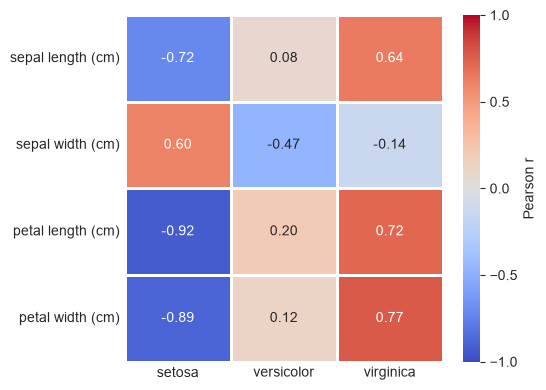

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))

sns.heatmap(
    corr_,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "Pearson r", "ticks": [-1, -0.5, 0, 0.5, 1]},
    ax=ax,
)

ax.tick_params(axis="both", length=0)
plt.tight_layout()
plt.show()

----
End of Documents